Using device: cuda


100%|██████████| 170M/170M [00:13<00:00, 13.1MB/s]



Starting Experiment 1: Simple CNN (3 Blocks) + Adam + Augmentation
Epoch [1/20] Train Loss: 1.7510 Acc: 35.65% | Val Loss: 1.4941 Acc: 45.75%
Epoch [2/20] Train Loss: 1.4936 Acc: 44.83% | Val Loss: 1.1767 Acc: 57.20%
Epoch [3/20] Train Loss: 1.3535 Acc: 50.60% | Val Loss: 1.0680 Acc: 61.55%
Epoch [4/20] Train Loss: 1.2641 Acc: 54.93% | Val Loss: 1.0387 Acc: 63.19%
Epoch [5/20] Train Loss: 1.1994 Acc: 56.87% | Val Loss: 0.9449 Acc: 66.59%
Epoch [6/20] Train Loss: 1.1454 Acc: 59.24% | Val Loss: 0.8907 Acc: 68.73%
Epoch [7/20] Train Loss: 1.1032 Acc: 60.77% | Val Loss: 0.8615 Acc: 69.91%
Epoch [8/20] Train Loss: 1.0664 Acc: 62.50% | Val Loss: 0.8182 Acc: 71.78%
Epoch [9/20] Train Loss: 1.0322 Acc: 63.63% | Val Loss: 0.7910 Acc: 72.56%
Epoch [10/20] Train Loss: 0.9950 Acc: 64.99% | Val Loss: 0.8012 Acc: 72.22%
Epoch [11/20] Train Loss: 0.9786 Acc: 65.49% | Val Loss: 0.7809 Acc: 73.20%
Epoch [12/20] Train Loss: 0.9468 Acc: 66.74% | Val Loss: 0.7363 Acc: 74.07%
Epoch [13/20] Train Loss: 0.9

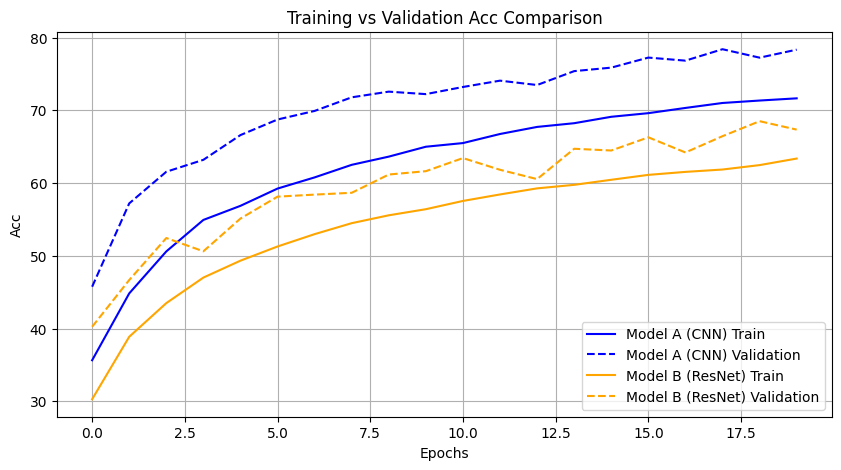

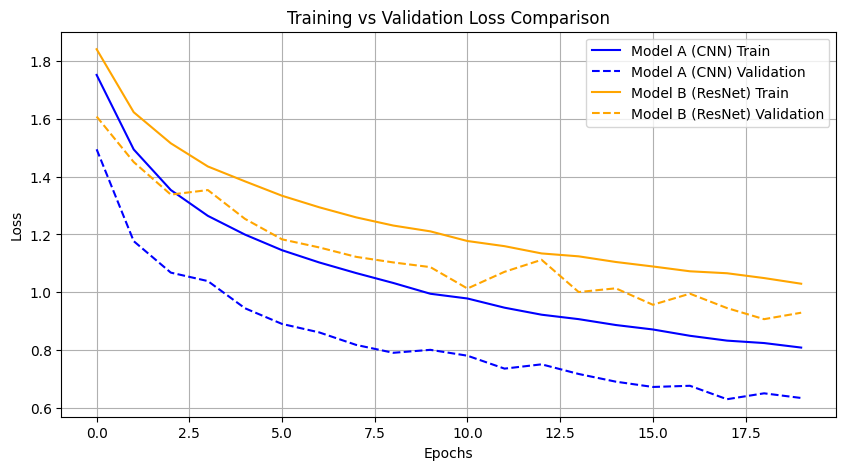


Final Results Comparison Table
                      Model Test Accuracy (%) Test Loss
Model A (Simple CNN - Adam)            78.45%    0.6355
Model B (ResNet-like - SGD)            66.69%    0.9449


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Data Requirements (Added Data Augmentation for Train set only)
transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),(0.2023, 0.1994, 0.2010))
])
transform_test = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),(0.2023, 0.1994, 0.2010))
])

print("Downloading and Loading CIFAR-10...")
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Partitioning
train_size = 40000
val_size = 10000
train_dataset, val_dataset = torch.utils.data.random_split(trainset, [train_size, val_size])

# Override val transform to remove augmentation
val_dataset.dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_test)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)

# 3 & 4. Model Requirements (Upgraded Simple CNN & ResNet-like)
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Output: 32x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Output: 16x16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # Output: 8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.skip = nn.Sequential()
        if in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.skip(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        out = self.relu(out)
        return out

class ResNetLike(nn.Module):
    def __init__(self):
        super(ResNetLike, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU()

        self.layer1 = self._make_layer(32, 32)
        self.layer2 = self._make_layer(32, 64)
        self.layer3 = self._make_layer(64, 128)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5)

    def _make_layer(self, in_channels, out_channels):
        return nn.Sequential(BasicBlock(in_channels, out_channels))

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# 5. Training & Evaluation Functions
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        # Validation Phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100 * val_correct / val_total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")

    return history

def evaluate_model(model, test_loader, criterion):
    model.eval()
    test_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return (test_loss / len(test_loader)), (100 * correct / total)

# 7. Experimentation Requirements
criterion = nn.CrossEntropyLoss()
epochs = 20

# Experiment 1
print("\n" + "="*50)
print("Starting Experiment 1: Simple CNN (3 Blocks) + Adam + Augmentation")
print("="*50)
model_a = SimpleCNN().to(device)
optimizer_a = optim.Adam(model_a.parameters(), lr=0.001)
history_a = train_model(model_a, train_loader, val_loader, optimizer_a, criterion, epochs)

# Experiment 2
print("\n" + "="*50)
print("Starting Experiment 2: ResNet-like (3 Layers) + SGD + Augmentation")
print("="*50)
model_b = ResNetLike().to(device)
optimizer_b = optim.SGD(model_b.parameters(), lr=0.01, momentum=0.9)
history_b = train_model(model_b, train_loader, val_loader, optimizer_b, criterion, epochs)

# 6. Evaluation Requirements
print("\n" + "="*50)
print("Evaluating Models on Test Dataset...")
print("="*50)
test_loss_a, test_acc_a = evaluate_model(model_a, test_loader, criterion)
test_loss_b, test_acc_b = evaluate_model(model_b, test_loader, criterion)

print(f"Model A (Simple CNN + Adam) -> Test Loss: {test_loss_a:.4f}, Test Accuracy: {test_acc_a:.2f}%")
print(f"Model B (ResNet-like + SGD) -> Test Loss: {test_loss_b:.4f}, Test Accuracy: {test_acc_b:.2f}%")

# 8. Visualization Requirements
def plot_comparison(hist_a, hist_b, name_a, name_b, metric):
    plt.figure(figsize=(10, 5))
    plt.plot(hist_a[f'train_{metric}'], label=f'{name_a} Train', color='blue')
    plt.plot(hist_a[f'val_{metric}'], label=f'{name_a} Validation', color='blue', linestyle='--')
    plt.plot(hist_b[f'train_{metric}'], label=f'{name_b} Train', color='orange')
    plt.plot(hist_b[f'val_{metric}'], label=f'{name_b} Validation', color='orange', linestyle='--')
    plt.title(f'Training vs Validation {metric.capitalize()} Comparison')
    plt.xlabel('Epochs')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)
    plt.show()

plot_comparison(history_a, history_b, 'Model A (CNN)', 'Model B (ResNet)', 'acc')
plot_comparison(history_a, history_b, 'Model A (CNN)', 'Model B (ResNet)', 'loss')

# 9. Results Requirements
results_df = pd.DataFrame({
    'Model': ['Model A (Simple CNN - Adam)', 'Model B (ResNet-like - SGD)'],
    'Test Accuracy (%)': [f"{test_acc_a:.2f}%", f"{test_acc_b:.2f}%"],
    'Test Loss': [f"{test_loss_a:.4f}", f"{test_loss_b:.4f}"]
})

print("\n" + "="*50)
print("Final Results Comparison Table")
print("="*50)
print(results_df.to_string(index=False))